# Concept Extraction Method Comparison

Compare **LLM, RAKE, YAKE, KeyBERT** by measuring how similar their extracted normalized concepts are to:
1. **Author keywords** — keywords provided by paper authors
2. **Labels** — manually assigned topic label per paper, except "unlabeled"

### Metrics
| Metric | What it captures |
|---|---|
| Token Jaccard | best word-overlap score between any concept and any reference phrase |
| Substring match | any concept contains the reference as substring (or vice versa) |
| Coverage | fraction of reference phrases token-covered by at least one concept |

In [1]:
import ast, re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

IMAGES_DIR = Path('images/concept_similarity')
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

METHODS = ['LLM', 'RAKE', 'YAKE', 'KeyBERT']
COLORS  = ['steelblue', 'darkorange', 'mediumseagreen', 'indianred']

def savefig(name):
    plt.savefig(IMAGES_DIR / f'{name}.png', bbox_inches='tight')

## Parsing helpers

In [2]:
def parse_concepts(val):
    return [str(concept).strip() for concept in ast.literal_eval(val) if concept]


def parse_keywords(s: str):
    s = s.strip()
    if s.startswith('[') and s.endswith(']'):
        s = s[1:-1]

    pattern = r"'([^']*)'"
    matches = re.findall(pattern, s)

    if not matches:
        return []

    return matches


STOPWORDS = {'a', 'an', 'the', 'of', 'in', 'for', 'on', 'with', 'and', 'or'}

def tokens(phrase):
    return {w for w in re.split(r'[\s\-_]+', phrase.lower())
            if w and w not in STOPWORDS}

## Load data

In [3]:
ground_truth = pd.read_csv('../data/raw/iclr_articles.csv', usecols=['id', 'keywords', 'labels'])
ground_truth['kw_list'] = ground_truth['keywords'].map(parse_keywords)
ground_truth['has_keywords'] = ground_truth['kw_list'].map(len) > 0

In [5]:
method_dfs = {}
for method in METHODS:
    df = pd.read_csv(f'../data/extracted_concepts/{method.lower()}/normalized_concepts.csv', usecols=['id', 'normalized_concepts'])
    df['concepts'] = df['normalized_concepts'].map(parse_concepts)
    method_dfs[method] = df[['id', 'concepts']]
    avg = df['concepts'].map(len).mean()
    print(f'{method}: {len(df):,} articles')

LLM: 11,349 articles
RAKE: 11,349 articles
YAKE: 11,349 articles
KeyBERT: 11,349 articles


In [6]:
# Merge each method with ground truth once
merged = {m: method_dfs[m].merge(ground_truth, on='id', how='inner') for m in METHODS}

## Similarity functions

In [7]:
def best_jaccard(concepts, references):
    """Best token-Jaccard over all (concept, reference) pairs."""
    if not concepts or not references:
        return 0.0
    best = 0.0
    for c in concepts:
        tc = tokens(c)
        for r in references:
            tr = tokens(r)
            union = tc | tr
            if union:
                best = max(best, len(tc & tr) / len(union))
    return best


def substring_match(concepts, references):
    """1 if any concept contains any reference as substring (or vice versa)."""
    for c in concepts:
        for r in references:
            if r in c or c in r:
                return 1.0
    return 0.0


def coverage(concepts, references):
    """Fraction of references that share at least one token with some concept."""
    if not references:
        return 0.0
    covered = sum(
        1 for r in references
        if any(tokens(c) & tokens(r) for c in concepts)
    )
    return covered / len(references)

## Score all methods

In [8]:
scores = {}

for method in METHODS:
    df = merged[method].copy()

    # vs. author keywords (only rows that have them)
    kw_df = df[df['has_keywords']].copy()
    kw_df['jaccard'] = kw_df.apply(lambda r: best_jaccard(r.concepts, r.kw_list), axis=1)
    kw_df['substring'] = kw_df.apply(lambda r: substring_match(r.concepts, r.kw_list), axis=1)
    kw_df['coverage'] = kw_df.apply(lambda r: coverage(r.concepts, r.kw_list), axis=1)

    # vs. label except "unlabeled" publications (treat single label as a one-item list)
    lbl_df = df[df['labels'] != 'unlabeled'].copy()
    lbl_df['lbl_ref'] = lbl_df['labels'].map(lambda x: [x.lower()])
    lbl_df['jaccard'] = lbl_df.apply(lambda r: best_jaccard(r.concepts, r.lbl_ref), axis=1)
    lbl_df['substring'] = lbl_df.apply(lambda r: substring_match(r.concepts, r.lbl_ref), axis=1)
    lbl_df['coverage'] = lbl_df.apply(lambda r: coverage(r.concepts, r.lbl_ref), axis=1)

    scores[method] = {'kw': kw_df, 'lbl': lbl_df}
    print(f'{method} done!')

LLM done!
RAKE done!
YAKE done!
KeyBERT done!


## Summary table

In [9]:
rows = []
for method in METHODS:
    kw  = scores[method]['kw']
    lbl = scores[method]['lbl']
    rows.append({
        'method': method,
        'KW Jaccard': kw['jaccard'].mean(),
        'KW Substring': kw['substring'].mean(),
        'KW Coverage': kw['coverage'].mean(),
        'LBL Jaccard': lbl['jaccard'].mean(),
        'LBL Substring': lbl['substring'].mean(),
        'LBL Coverage': lbl['coverage'].mean(),
    })

summary = pd.DataFrame(rows).set_index('method')
summary.style.highlight_max(axis=0, color='lightgreen').format('{:.3f}')

,KW Jaccard,KW Substring,KW Coverage,LBL Jaccard,LBL Substring,LBL Coverage
method,,,,,,
LLM,0.686,0.761,0.775,0.214,0.275,0.490
RAKE,0.522,0.612,0.633,0.139,0.191,0.396
YAKE,0.634,0.767,0.587,0.164,0.215,0.350
KeyBERT,0.445,0.496,0.615,0.134,0.173,0.386


## Bar chart — all metrics side by side

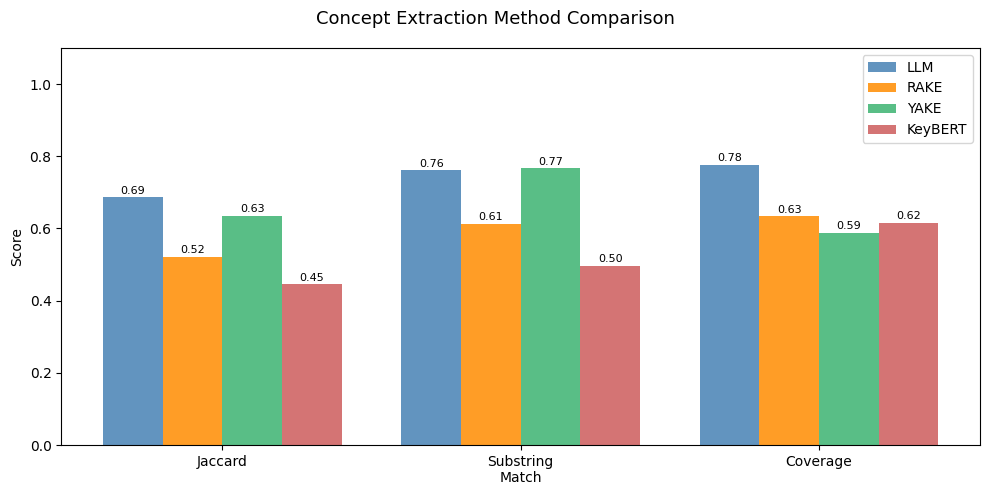

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

metric_groups = [
    (['KW Jaccard', 'KW Substring', 'KW Coverage'], 'vs. Author Keywords')
]

x = np.arange(3)
w = 0.2

for metric_cols, title in metric_groups:
    for i, (method, color) in enumerate(zip(METHODS, COLORS)):
        vals = summary.loc[method, metric_cols].values
        bars = ax.bar(x + i * w, vals, w, label=method, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + w / 2, bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(['Jaccard', 'Substring\nMatch', 'Coverage'])
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.legend()
    break

plt.suptitle('Concept Extraction Method Comparison', fontsize=13)
plt.tight_layout()
savefig('01_method_comparison_bar')
plt.show()

## Overall ranking

Method Ranking (lower = better)
         avg_rank
method           
LLM          1.17
YAKE         2.50
RAKE         2.67
KeyBERT      3.67

Best overall: LLM


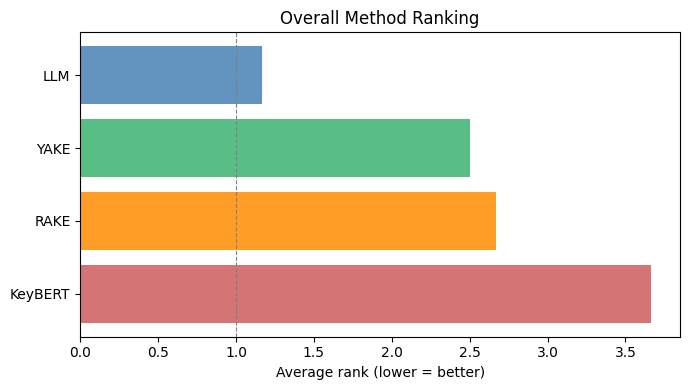

,KW Jaccard,KW Substring,KW Coverage,LBL Jaccard,LBL Substring,LBL Coverage
method,,,,,,
LLM,0.686,0.761,0.775,0.214,0.275,0.490
RAKE,0.522,0.612,0.633,0.139,0.191,0.396
YAKE,0.634,0.767,0.587,0.164,0.215,0.350
KeyBERT,0.445,0.496,0.615,0.134,0.173,0.386


In [11]:
# Rank methods on each metric (1 = best), then average rank
ranks = summary.rank(ascending=False, axis=0)
ranks['avg_rank'] = ranks.mean(axis=1)
ranks = ranks.sort_values('avg_rank')

print('Method Ranking (lower = better)')
print(ranks[['avg_rank']].round(2).to_string())
print(f'\nBest overall: {ranks.index[0].upper()}')

colors_sorted = [COLORS[METHODS.index(m)] for m in ranks.index]
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ranks.index[::-1], ranks['avg_rank'].values[::-1],
        color=colors_sorted[::-1], alpha=0.85)
ax.set_xlabel('Average rank (lower = better)')
ax.set_title('Overall Method Ranking')
ax.axvline(1, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
savefig('02_overall_ranking')
plt.show()

summary.round(3)